In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# --- STEP A: EXTRACTION ---
zip_path = '/content/drive/MyDrive/bank_dataset/bank-data.zip'
extract_path = '/content/bank_data_new'

if os.path.exists(zip_path):
    !unzip -o "{zip_path}" -d "{extract_path}"
    print("✅ Files restored from Drive.")
else:
    print("❌ Critical Error: Can't find the zip file in your Drive folder 'bank_dataset'.")

# --- STEP B: LOAD DATA ---
# We search for the CSV inside the new folder
csv_path = extract_path + '/bank-data/bank-full.csv'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path, sep=';')
    print("✅ Data loaded successfully.")

    # --- STEP C: LOGISTIC REGRESSION ---
    # 1. Convert text categories to numbers
    df_final = pd.get_dummies(df, drop_first=True)

    # 2. Split Features (X) and Target (y)
    X = df_final.drop('y_yes', axis=1)
    y = df_final['y_yes']

    # 3. Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. Scale and Train
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)

    # 5. Output Results
    y_pred = model.predict(X_test_scaled)
    print("\n--- MODEL PERFORMANCE ---")
    print(classification_report(y_test, y_pred))
else:
    print("❌ Found the folder, but the CSV file is missing inside it.")

Archive:  /content/drive/MyDrive/bank_dataset/bank-data.zip
   creating: /content/bank_data_new/bank-data/
  inflating: /content/bank_data_new/__MACOSX/._bank-data  
  inflating: /content/bank_data_new/bank-data/.DS_Store  
  inflating: /content/bank_data_new/__MACOSX/bank-data/._.DS_Store  
  inflating: /content/bank_data_new/bank-data/bank-full.csv  
  inflating: /content/bank_data_new/__MACOSX/bank-data/._bank-full.csv  
✅ Files restored from Drive.
✅ Data loaded successfully.

--- MODEL PERFORMANCE ---
              precision    recall  f1-score   support

       False       0.92      0.98      0.94      7952
        True       0.65      0.34      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.88      0.90      0.88      9043



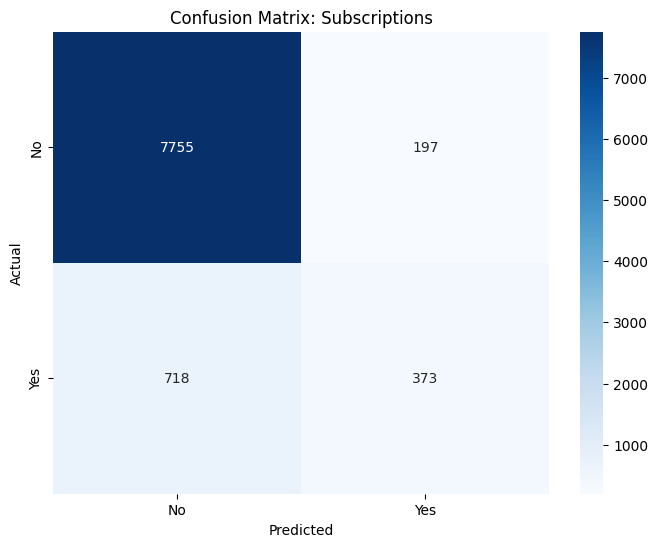

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Subscriptions')
plt.show()

In [15]:
import numpy as np

# Get the coefficients
importance = model.coef_[0]
feature_names = X.columns

# Create a DataFrame for easy viewing
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Show the top 10 most influential features
print("Top 10 Factors for Subscription:")
print(feature_importance.head(10))

Top 10 Factors for Subscription:
                Feature  Importance
3              duration    1.081693
40     poutcome_success    0.404305
21   education_tertiary    0.169913
34            month_mar    0.157349
33            month_jun    0.142463
37            month_oct    0.109631
20  education_secondary    0.104746
38            month_sep    0.099545
2                   day    0.084230
14          job_student    0.047229


In [16]:
import joblib

# Save the model to your Google Drive
joblib.dump(model, '/content/drive/MyDrive/bank_dataset/term_deposit_model.pkl')
print("✅ Model saved to Drive!")

✅ Model saved to Drive!


Overall Accuracy: 89.88%
------------------------------
Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.98      0.94      7952
        True       0.65      0.34      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.88      0.90      0.88      9043



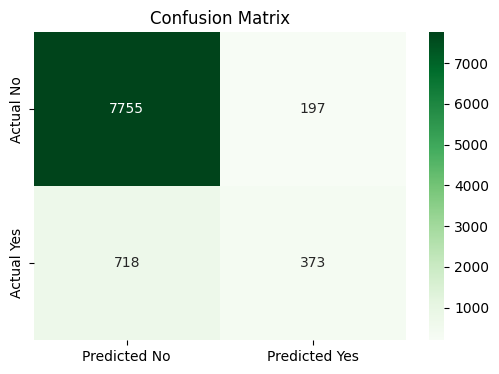

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc:.2%}")
print("-" * 30)

# 2. Detailed Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 3. Visual Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix')
plt.show()